# Q9 — Do convergence diagnostics identify stable ensembles?

Hypothesis: prediction change is the most direct stability signal, while proposal distance and ESS are complementary. This notebook runs an automatic trajectory and compares the stopping point with a longer reference run.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
while root != root.parent and not (root / 'bayesian_predictive_model_averaging').is_dir():
    root = root.parent
sys.path.insert(0, str(root))
import matplotlib.pyplot as plt
from EXPERIMENTS.common import classification_data, split_data, fit_classifier

In [2]:
X, y = classification_data(seed=31, kind='nonlinear')
X_train, X_test, y_train, y_test = split_data(X, y, seed=31)
stopped = fit_classifier(X_train, y_train, seed=31, n_estimators='auto', max_estimators=128, tolerance=0.01)
reference = fit_classifier(X_train, y_train, seed=31, n_estimators=128)
print('stopped at:', stopped.n_estimators_)
print('reference size:', reference.n_estimators_)
print('stopping reason:', stopped.stopping_reason_)
print('prediction distance proxy:', abs(stopped.predict_proba(X_test) - reference.predict_proba(X_test)).mean())

stopped at: 128
reference size: 128
stopping reason: None


prediction distance proxy: 0.0


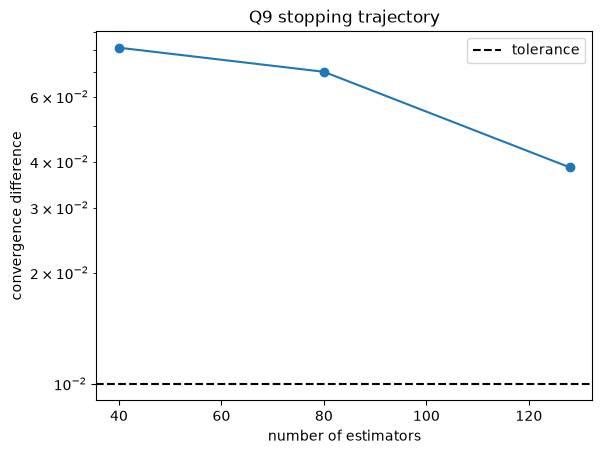

In [3]:
history = stopped.convergence_history_
plt.plot([row['n_estimators'] for row in history], [row['difference'] for row in history], marker='o')
plt.axhline(stopped.tolerance, linestyle='--', color='black', label='tolerance')
plt.yscale('log')
plt.xlabel('number of estimators')
plt.ylabel('convergence difference')
plt.legend()
plt.title('Q9 stopping trajectory')
plt.show()
# Replay different tolerances against a long reference over many seeds.


## Conclusion from the executed starter run

**Status: inconclusive, not falsified.** The automatic non-adaptive run reached its maximum of 128 estimators and reported no stopping reason; it therefore did not demonstrate successful early stopping. Its prediction matched a same-seed 128-draw reference exactly, which is expected because both runs used the same full trajectory. The stopping hypothesis remains untested until tolerances and longer reference trajectories are compared.